In [1]:
# ReACTEmu Boost Validation Plot
# Author: CLOE Team

import numpy as np
import matplotlib.pyplot as plt

from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations
from cloelib.cosmology.ReACTEmu_cosmology import MGemuNonlinearBoost


/opt/anaconda3/envs/cloe_implementation/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/opt/anaconda3/envs/cloe_implementation/lib/python3.10/site-packages/MGEmu


In [2]:
# Define validation configuration
validation_config = {
    "fr": {
        "mgparam": 1e-5,
        "file": "validation_data/fR_validation_data.dat"
    },
    "dgp": {
        "mgparam": 0.1,
        "file": "validation_data/dgp_validation_data.dat"
    }
}

# Redshifts and their corresponding column indices in the data files
redshifts = [0.1, 0.478, 0.785, 1.5]
z_cols = {0.1: 4, 0.478: 3, 0.785: 2, 1.5: 1}

# Shared CAMB background (from validation cosmology)
camb = CAMBBackground(
    H0=67.39774575153639,
    Omega_b0=0.05062684354655124,
    Omega_cdm0=0.3164470361777248 - 0.05062684354655124,
    Omega_k0=0.0,
    As=2.1977194699875245e-9,
    ns=0.9423180532642602,
    mnu=0.0,
    w0=-1,
    wa=0,
    gamma_MG=0.0,
)

linear = CAMBLinearPerturbations(camb, np.array(redshifts))


Note: redshifts have been re-sorted (earliest first)



📊 Plotting boost comparison for model: fr
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


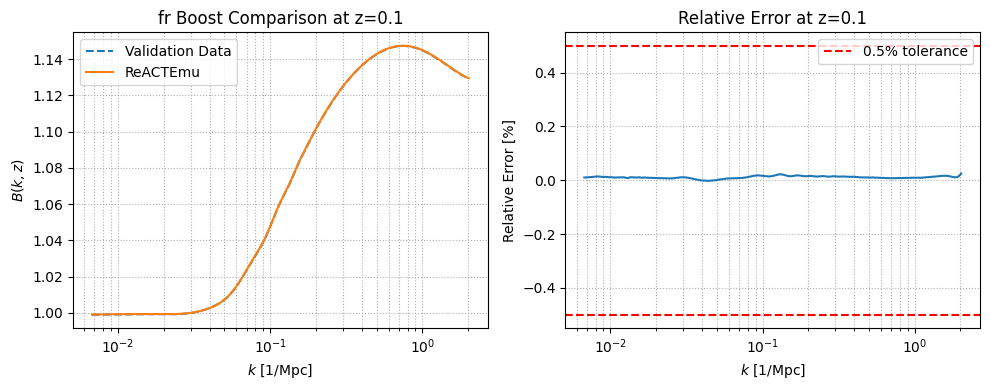

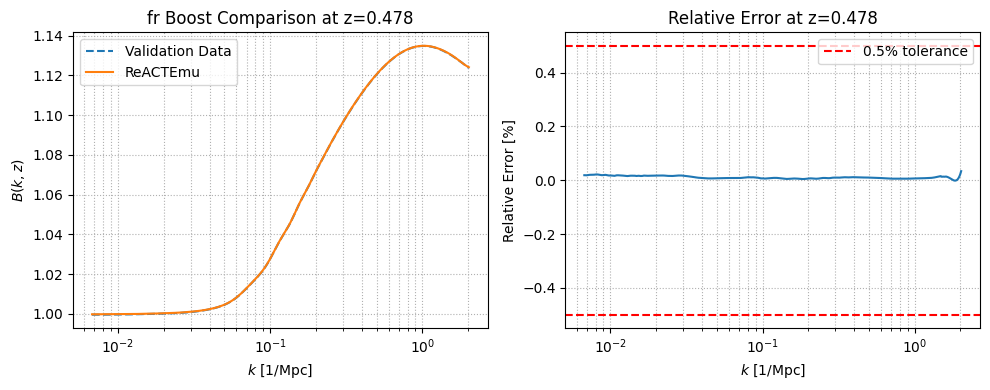

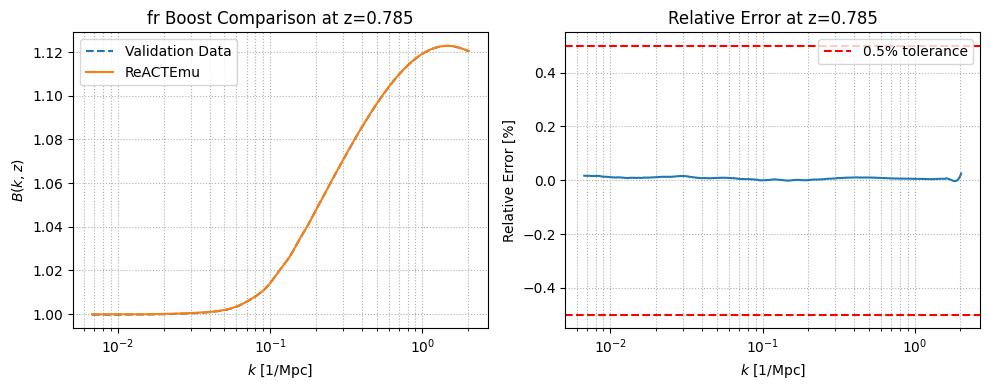

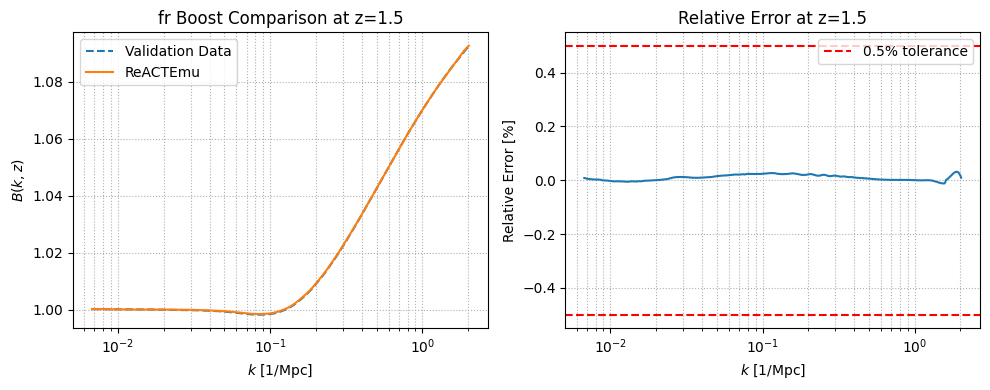


📊 Plotting boost comparison for model: dgp
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


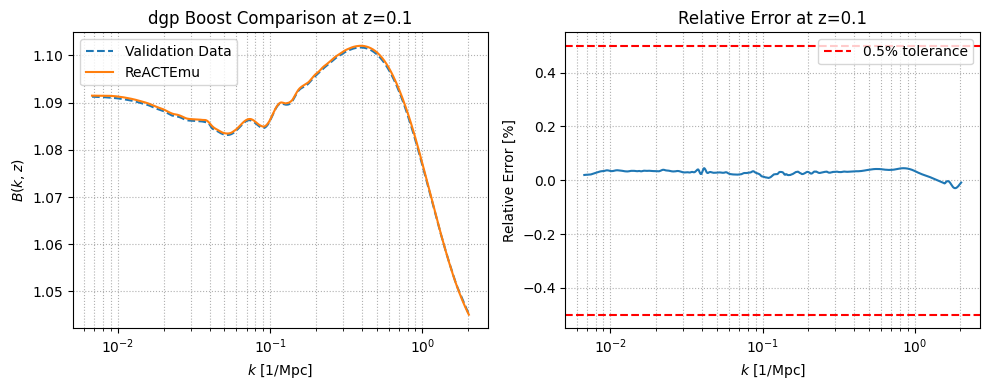

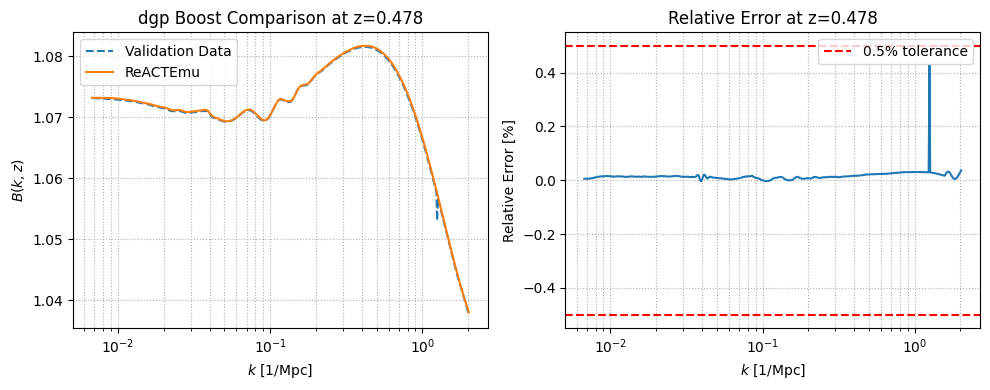

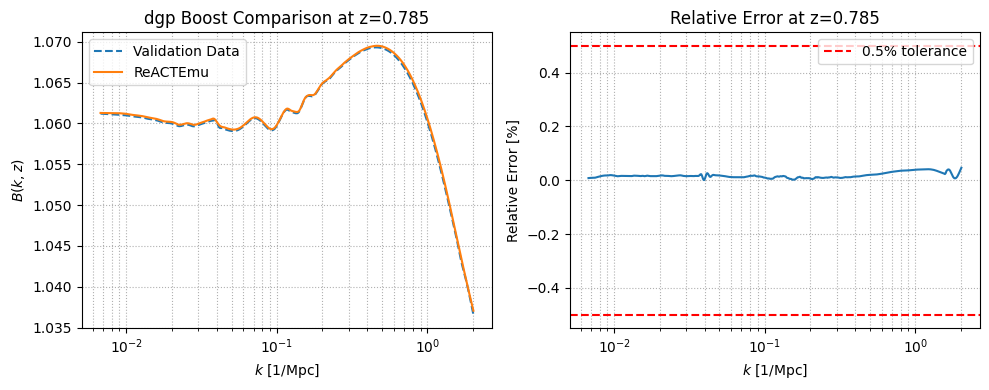

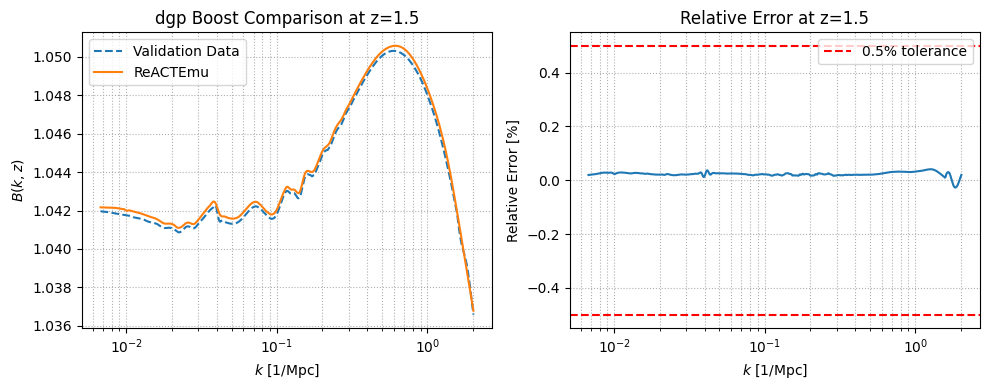

In [6]:
# Loop through each model
for model, cfg in validation_config.items():
    mgparam = cfg["mgparam"]
    filepath = cfg["file"]

    print(f"\n📊 Plotting boost comparison for model: {model}")

    # Load data
    data = np.loadtxt(filepath)
    k_vals = data[:, 0] * camb.H0/100  # Convert from h/Mpc to 1/Mpc

    # Compute emulator boost
    emu = MGemuNonlinearBoost(camb, linear, np.array(redshifts), model, mgparam)
    interp = emu.MGboost_interp

    # Plot for each z
    for z in redshifts:
        B_model = interp(z, k_vals, grid=False)
        B_data = data[:, z_cols[z]]

        rel_err = 100 * (B_model - B_data) / B_data

        plt.figure(figsize=(10, 4))

        # Absolute comparison
        plt.subplot(1, 2, 1)
        plt.title(f"{model} Boost Comparison at z={z}")
        plt.plot(k_vals, B_data, label="Validation Data", linestyle="dashed")
        plt.plot(k_vals, B_model, label="ReACTEmu", linestyle="solid")
        plt.xlabel(r"$k$ [1/Mpc]")
        plt.ylabel(r"$B(k,z)$")
        plt.xscale("log")
        plt.legend()
        plt.grid(True, which="both", linestyle=":")

        # Relative error
        plt.subplot(1, 2, 2)
        plt.title(f"Relative Error at z={z}")
        plt.plot(k_vals, rel_err)
        plt.axhline(0.5, color='r', linestyle='--', label="0.5% tolerance")
        plt.axhline(-0.5, color='r', linestyle='--')
        plt.xlabel(r"$k$ [1/Mpc]")
        plt.ylabel(r"Relative Error [%]")
        plt.xscale("log")
        plt.grid(True, which="both", linestyle=":")
        plt.legend()

        plt.tight_layout()
        plt.show()
